# Investigacao - Amortizacao incorreta -> preco negativo (V1 vs V2)

Compara o mesmo evento de **vencimento/amortizacao** no **Engine V1 (Supabase, PROD)** e no **Engine V2 (copia LOCAL, db `engine`)**.

Ativos: token `NXFSE26-1`, serie `CR-FGTS-30-01-SENIOR`, securitizacao-mae `CR-FGTS-30`.

## Guardrails (somente leitura - NUNCA escrever em V1 prod nem em V2)

1. **Servidor read-only**: toda conexao abre com `default_transaction_read_only=on` -> o Postgres rejeita qualquer escrita na sessao.
2. **Filtro de SQL no app**: `assert_select_only()` so deixa passar UM `SELECT`/`WITH`; bloqueia `;` interno e qualquer palavra de DDL/DML (INSERT/UPDATE/DELETE/DROP/ALTER/...). Pega ate `WITH ... DELETE`.
3. **Sempre ROLLBACK**: cada query roda numa transacao que termina em rollback - nada e comitado.

Credenciais no `.env` (gitignored). `V1_DATABASE_URL` deve usar um papel **read-only**; enquanto vazio, as celulas do V1 sao puladas.

In [1]:
import os, re, pathlib
import pandas as pd
from sqlalchemy import create_engine, text

# ---------- localizar e carregar o .env ----------
def find_env():
    cands = [pathlib.Path('.env'), pathlib.Path.cwd() / '.env']
    for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        cands.append(parent / '.env')
    for c in cands:
        if c.exists():
            return c
    return pathlib.Path('.env')

def load_env(path):
    env = {}
    if path.exists():
        for line in path.read_text(encoding='utf-8').splitlines():
            line = line.strip()
            if line and not line.startswith('#') and '=' in line:
                k, v = line.split('=', 1)
                env[k.strip()] = v.strip()
    return env

ENV_PATH = find_env()
ENV = load_env(ENV_PATH)
V2_URL = ENV.get('DATABASE_URL', '').strip()
V1_URL = ENV.get('V1_DATABASE_URL', '').strip()
print('.env:', ENV_PATH)

# ---------- GUARDRAIL 1: read-only no servidor para toda conexao ----------
RO_ARGS = {'options': '-c default_transaction_read_only=on'}
def make_engine(url):
    if not url:
        return None
    return create_engine(url, connect_args=RO_ARGS, pool_pre_ping=True)

eng_v2 = make_engine(V2_URL)
eng_v1 = make_engine(V1_URL)

# ---------- GUARDRAIL 2: so SELECT/WITH, statement unico, sem DDL/DML ----------
FORBIDDEN = {
    'insert','update','delete','drop','alter','truncate','create','grant','revoke',
    'merge','copy','call','do','vacuum','refresh','comment','reindex','cluster',
    'lock','set','reset','commit','rollback','savepoint','prepare','execute',
    'listen','notify','begin'
}
def strip_comments(sql):
    no_line = ' '.join(ln.split('--', 1)[0] for ln in sql.splitlines())
    s = no_line
    while '/*' in s and '*/' in s:
        i = s.index('/*'); j = s.index('*/', i + 2)
        s = s[:i] + ' ' + s[j + 2:]
    return s.strip()

def assert_select_only(sql):
    s = strip_comments(sql)
    if not s:
        raise ValueError('SQL vazio.')
    core = s.rstrip(';').strip()
    if ';' in core:
        raise ValueError('Apenas UM statement por chamada (sem ; interno).')
    low = core.lower()
    if not (low.startswith('select') or low.startswith('with')):
        raise ValueError('Bloqueado: so SELECT/WITH e permitido (read-only).')
    bad = set(re.findall('[a-z_]+', low)) & FORBIDDEN
    if bad:
        raise ValueError('Bloqueado: palavra de escrita/DDL -> ' + ', '.join(sorted(bad)))
    return core

# ---------- GUARDRAIL 3: transacao read-only + ROLLBACK sempre ----------
def _run(engine, sql, params, label):
    if engine is None:
        print('[' + label + '] conexao nao configurada -> pulando (preencha a URL no .env).')
        return None
    core = assert_select_only(sql)
    with engine.connect() as conn:
        tx = conn.begin()
        try:
            return pd.read_sql(text(core), conn, params=params or {})
        finally:
            tx.rollback()

def run_v2(sql, params=None):
    return _run(eng_v2, sql, params, 'V2')
def run_v1(sql, params=None):
    return _run(eng_v1, sql, params, 'V1')

# ---------- sanidade ----------
print('V2 engine:', 'OK' if eng_v2 else 'sem DATABASE_URL')
print('V1 engine:', 'configurado' if eng_v1 else 'NAO configurado (preencha V1_DATABASE_URL)')
if eng_v2 is not None:
    _n = run_v2('SELECT count(*) AS n FROM valuations')
    print('V2 valuations:', int(_n['n'][0]), '(esperado ~16.328.680; se vier 26 voce esta no container Docker errado)')

.env: .env
V2 engine: OK
V1 engine: configurado


V2 valuations: 16328680 (esperado ~16.328.680; se vier 26 voce esta no container Docker errado)


In [2]:
# auto-teste dos guardrails: estas chamadas DEVEM levantar erro (nada executa no banco)
for _sql in ['DELETE FROM valuations', 'UPDATE valuations SET clean_price = 0',
             'WITH x AS (SELECT 1) DELETE FROM valuations', 'SELECT 1; DROP TABLE t']:
    try:
        assert_select_only(_sql)
        print('FALHOU (deveria bloquear):', _sql)
    except ValueError as e:
        print('bloqueado OK:', _sql, '->', e)
print('SELECT valido passa:', bool(assert_select_only('SELECT 1')))

bloqueado OK: DELETE FROM valuations -> Bloqueado: so SELECT/WITH e permitido (read-only).
bloqueado OK: UPDATE valuations SET clean_price = 0 -> Bloqueado: so SELECT/WITH e permitido (read-only).
bloqueado OK: WITH x AS (SELECT 1) DELETE FROM valuations -> Bloqueado: palavra de escrita/DDL -> delete
bloqueado OK: SELECT 1; DROP TABLE t -> Apenas UM statement por chamada (sem ; interno).
SELECT valido passa: True


## FASE 1 (V2) - Identificar os ATIVOS afetados e a DATA

### 1.1 Quais ativos tem valuation com preco (clean_price) negativo, e em que janela?

In [3]:
run_v2('''
SELECT e.name AS ativo, rt.name AS classe, m.name AS metodologia,
       count(*) AS qtd_neg, min(v.clean_price) AS menor, max(v.clean_price) AS maior,
       min(v.date)::date AS primeira_data, max(v.date)::date AS ultima_data
FROM valuations v
JOIN entities e ON e.id = v.asset_id
LEFT JOIN reference_tables rt ON rt.id = e.reference_table_id
LEFT JOIN valuation_methodologies m ON m.id = v.methodology_id
WHERE v.clean_price < 0
GROUP BY e.name, rt.name, m.name
ORDER BY qtd_neg DESC, ativo
''')
# esperado: CR-FGTS-30-01-SENIOR (securitization_series) e NXFSE26-1 (tokens), 18 cada, -1.42183, 2026-05-15..2026-06-01

,ativo,classe,metodologia,qtd_neg,menor,maior,primeira_data,ultima_data
0,CR-FGTS-30-01-SENIOR,securitization_series,amortized_cost,18,-1.42183,-1.42183,2026-05-15,2026-06-01
1,NXFSE26-1,tokens,amortized_cost,18,-1.42183,-1.42183,2026-05-15,2026-06-01


### 1.2 Metadados e vinculo token <-> serie <-> securitizacao-mae
(a serie liga na mae por `securitization_series.issuer_id = securitizations.id`)

In [4]:
run_v2('''
SELECT tok_e.name AS token, tok.maturity_date AS token_maturity,
       tok.issuance_price, tok.face_value AS token_face_value,
       ser_e.name AS serie, sen.name AS senioridade,
       ser.issuance_date AS serie_emissao, ser.maturity_date AS serie_vencimento,
       ser.initial_price AS serie_face, ser.quantity AS serie_qtd,
       ser.indexer_percentage, ser.spread_over_indexer,
       sec_e.name AS securitizacao_mae, sec.issuance_number
FROM tokens tok
JOIN entities tok_e ON tok_e.id = tok.id
JOIN entities mae_e ON mae_e.id = tok.issuer_id
JOIN securitizations sec ON sec.id = mae_e.id
JOIN entities sec_e ON sec_e.id = sec.id
JOIN securitization_series ser ON ser.issuer_id = sec.id
JOIN entities ser_e ON ser_e.id = ser.id
JOIN seniorities sen ON sen.id = ser.seniority_id
WHERE tok_e.name = 'NXFSE26-1'
''')

,token,token_maturity,issuance_price,token_face_value,serie,senioridade,serie_emissao,serie_vencimento,serie_face,serie_qtd,indexer_percentage,spread_over_indexer,securitizacao_mae,issuance_number
0,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-01-SENIOR,SENIOR,2026-04-07,2026-05-15,100.0,1160,1.0,0.159792,CR-FGTS-30,30
1,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-02-SENIOR,SENIOR,2026-04-07,2026-06-15,100.0,1167,1.0,0.151253,CR-FGTS-30,30
2,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-03-SENIOR,SENIOR,2026-04-07,2026-07-15,100.0,1120,1.0,0.154815,CR-FGTS-30,30
3,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-04-SENIOR,SENIOR,2026-04-07,2026-08-17,100.0,1181,1.0,0.154418,CR-FGTS-30,30
4,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-05-SENIOR,SENIOR,2026-04-07,2026-09-15,100.0,1212,1.0,0.153754,CR-FGTS-30,30
5,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-06-SENIOR,SENIOR,2026-04-07,2026-10-15,100.0,1051,1.0,0.153352,CR-FGTS-30,30
6,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-07-SENIOR,SENIOR,2026-04-07,2026-11-16,100.0,1077,1.0,0.153962,CR-FGTS-30,30
7,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-08-SENIOR,SENIOR,2026-04-07,2026-12-15,100.0,1175,1.0,0.154726,CR-FGTS-30,30
8,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-09-SENIOR,SENIOR,2026-04-07,2027-01-15,100.0,1061,1.0,0.155565,CR-FGTS-30,30
9,NXFSE26-1,2026-05-15,100.0,101.54,CR-FGTS-30-10-SENIOR,SENIOR,2026-04-07,2027-02-15,100.0,1030,1.0,0.155767,CR-FGTS-30,30


### 1.3 Trajetoria diaria do clean_price (serie) em torno do vencimento
Mostra o dia exato em que cruza de +100 para -1.42183 (= maturity_date 2026-05-15).

,id,data,clean_price,accrued_interest,cash_flow,vigente
0,24503991,2026-05-10,100.00000,1.123957,0.00000,False
1,24504112,2026-05-11,100.00000,1.183461,0.00000,False
2,24504232,2026-05-12,100.00000,1.243001,0.00000,False
3,24504352,2026-05-13,100.00000,1.302575,0.00000,False
4,24504472,2026-05-14,100.00000,1.362185,0.00000,False
5,24504592,2026-05-15,100.00000,1.421829,0.00000,False
6,23117348,2026-05-15,-1.42183,1.302575,1.42183,False
7,24504770,2026-05-16,-1.42183,1.302575,0.00000,False
8,24504890,2026-05-17,-1.42183,1.302575,0.00000,False
9,24505010,2026-05-18,-1.42183,1.302505,0.00000,False


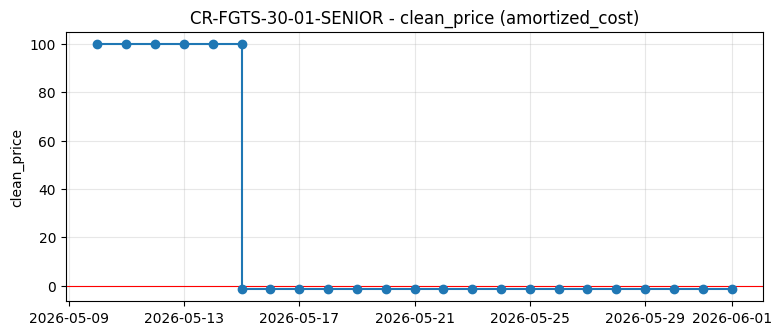

In [5]:
import matplotlib.pyplot as plt
from IPython.display import display

df13 = run_v2('''
SELECT v.id, v.date::date AS data, v.clean_price, v.accrued_interest,
       v.cash_flow, v.last_valuation_flag AS vigente
FROM valuations v
JOIN entities e ON e.id = v.asset_id
JOIN valuation_methodologies m ON m.id = v.methodology_id
WHERE e.name = 'CR-FGTS-30-01-SENIOR' AND m.name = 'amortized_cost'
  AND v.date::date BETWEEN '2026-05-10' AND '2026-06-01'
ORDER BY v.date, v.id
''')
display(df13)
if df13 is not None and len(df13):
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.axhline(0, color='red', linewidth=0.8)
    ax.plot(pd.to_datetime(df13['data']), df13['clean_price'].astype(float), marker='o')
    ax.set_title('CR-FGTS-30-01-SENIOR - clean_price (amortized_cost)')
    ax.set_ylabel('clean_price'); ax.grid(True, alpha=0.3)
    plt.show()

## FASE 2 (V2) - O EVENTO e os VALORES que causaram o valuation negativo

### 2.1 As DUAS valuations de 2026-05-15 (serie e token): diaria normal vs evento de vencimento

In [6]:
run_v2('''
SELECT v.id, e.name AS ativo, v.date AS data_hora, v.clean_price,
       v.accrued_interest, v.cash_flow, v.last_valuation_flag AS vigente,
       CASE WHEN v.cash_flow <> 0 THEN 'EVENTO (vencimento)' ELSE 'diario normal' END AS tipo
FROM valuations v
JOIN entities e ON e.id = v.asset_id
JOIN valuation_methodologies m ON m.id = v.methodology_id
WHERE e.name IN ('CR-FGTS-30-01-SENIOR','NXFSE26-1') AND m.name = 'amortized_cost'
  AND v.date::date = '2026-05-15'
ORDER BY e.name, v.id
''')

,id,ativo,data_hora,clean_price,accrued_interest,cash_flow,vigente,tipo
0,23117348,CR-FGTS-30-01-SENIOR,2026-05-15 12:00:00+00:00,-1.42183,1.302575,1.42183,False,EVENTO (vencimento)
1,24504592,CR-FGTS-30-01-SENIOR,2026-05-15 03:00:00+00:00,100.00000,1.421829,0.00000,False,diario normal
2,23117349,NXFSE26-1,2026-05-15 12:00:00+00:00,-1.42183,1.302575,1.42183,False,EVENTO (vencimento)
3,24504652,NXFSE26-1,2026-05-15 03:00:00+00:00,100.00000,1.421829,0.00000,False,diario normal


### 2.2 Posicoes/transacoes de 2026-05-15 ligadas a CR-FGTS-30 (o evento de caixa)

In [7]:
run_v2('''
SELECT p.id, p.date::date AS data, a.name AS ativo, h.name AS holder,
       fa.name AS conta_contabil, tt.name AS tipo_transacao,
       p.variation, p.total_quantity AS saldo, p.block_id
FROM positions p
JOIN entities a ON a.id = p.asset_id
JOIN entities h ON h.id = p.holder_id
LEFT JOIN financial_accounts fa ON fa.id = p.financial_account_id
LEFT JOIN transaction_types tt ON tt.id = p.transaction_type_id
WHERE p.date::date = '2026-05-15'
  AND (h.name IN ('CR-FGTS-30','CR-FGTS-30-01-SENIOR','NXFSE26-1')
    OR a.name IN ('CR-FGTS-30','CR-FGTS-30-01-SENIOR','NXFSE26-1'))
ORDER BY tt.name, p.id
''')

,id,data,ativo,holder,conta_contabil,tipo_transacao,variation,saldo,block_id
0,4548186,2026-05-15,BRL,CR-FGTS-30,cash and equivalents,AMORTIZATION,-1058.58,13129.16,2605197919787309756


### 2.3 PROVA aritmetica: custo amortizado = face * (1 - fracao_acumulada)
Com face=100 e clean=-1.42183 => fracao=1.0142183 (101.42%). O excedente acima de 100% e exatamente o cupom/face => **juro foi contabilizado como amortizacao de principal**.

In [8]:
run_v2('''
SELECT e.name AS ativo, ser.initial_price AS face, v.clean_price AS clean_observado,
       v.cash_flow AS cupom_pago,
       round(1 - v.clean_price / ser.initial_price, 8) AS fracao_amortizada_implicita,
       round((1 - v.clean_price / ser.initial_price) - 1, 8) AS excedente_acima_100pct,
       round(v.cash_flow / ser.initial_price, 8) AS cupom_como_fracao_face
FROM valuations v
JOIN entities e ON e.id = v.asset_id
JOIN securitization_series ser ON ser.id = v.asset_id
WHERE e.name = 'CR-FGTS-30-01-SENIOR' AND v.clean_price < 0
ORDER BY v.date
LIMIT 1
''')
# excedente_acima_100pct == cupom_como_fracao_face  ->  a prova (0.0142183 == 0.0142183)

,ativo,face,clean_observado,cupom_pago,fracao_amortizada_implicita,excedente_acima_100pct,cupom_como_fracao_face
0,CR-FGTS-30-01-SENIOR,100.0,-1.42183,1.42183,1.014218,0.014218,0.014218


### 2.4 Quanto saiu de caixa? (via `block_id`) e quantos tokens foram vendidos

Nem todos os 1160 tokens foram vendidos — o **CR-FGTS-30 retem a maior parte** e so uma fracao esta com terceiros. Entao a saida de caixa **nao** e `1160 x 101.42`. Para ver a partida dobrada do evento, agrupamos as posicoes pelo `block_id` (todas as linhas de uma mesma transacao).

In [33]:
# 2.4a Holdings do token NXFSE26-1: quanto o CR-FGTS-30 retem vs quanto esta com terceiros (vendido).
run_v2('''
SELECT h.name AS holder, fa.name AS conta, p.total_quantity AS qtd,
       CASE WHEN h.name = 'CR-FGTS-30' THEN 'retido pelo CR' ELSE 'com terceiros' END AS situacao
FROM positions p
JOIN entities a ON a.id = p.asset_id
JOIN entities h ON h.id = p.holder_id
LEFT JOIN financial_accounts fa ON fa.id = p.financial_account_id
WHERE a.name = 'NXFSE26-1' AND p.last_position_flag AND p.total_quantity <> 0
ORDER BY p.total_quantity DESC
''')
# CR-FGTS-30 retem 1104 (token investments) + 56 (integralized) = 1160; com terceiros: 56 (NXTPL28-1 40 + NXTPD27-1 15 + NXTPC31-1 1).

,holder,conta,qtd,situacao
0,CR-FGTS-30,token investments,1104.0,retido pelo CR
1,CR-FGTS-30,integralized tokens,56.0,retido pelo CR
2,NXTPL28-1,token investments,40.0,com terceiros
3,NXTPD27-1,token investments,15.0,com terceiros
4,NXTPC31-1,token investments,1.0,com terceiros


In [10]:
# 2.4b A saida de caixa do vencimento vista pelo block_id (todas as linhas da MESMA transacao).
# Pega dinamicamente o(s) block_id da AMORTIZATION de 15/05 do CR-FGTS-30 e lista o bloco inteiro.
run_v2('''
WITH blocos AS (
    SELECT DISTINCT p.block_id
    FROM positions p
    JOIN entities h ON h.id = p.holder_id
    JOIN transaction_types tt ON tt.id = p.transaction_type_id
    WHERE p.date::date = '2026-05-15' AND h.name = 'CR-FGTS-30' AND tt.name = 'AMORTIZATION'
)
SELECT p.block_id, p.id, p.date::date AS data,
       a.name AS ativo, h.name AS holder, fa.name AS conta, tt.name AS tx,
       p.variation, p.total_quantity AS saldo
FROM positions p
JOIN entities a ON a.id = p.asset_id
JOIN entities h ON h.id = p.holder_id
LEFT JOIN financial_accounts fa ON fa.id = p.financial_account_id
JOIN transaction_types tt ON tt.id = p.transaction_type_id
WHERE p.block_id IN (SELECT block_id FROM blocos)
ORDER BY p.block_id, p.id
''')
# ACHADO: o bloco tem UMA UNICA linha (BRL -1058.58, saida de caixa do CR) -- NAO ha baixa de token/serie
# nem caixa para os holders externos. Em V2 o vencimento ficou INCOMPLETO (so a perna de caixa),
# alem do clean_price negativo. (No V1 a amortizacao sai por unidade = 101.42183; ver secao 3.)

,block_id,id,data,ativo,holder,conta,tx,variation,saldo
0,2605197919787309756,4548186,2026-05-15,BRL,CR-FGTS-30,cash and equivalents,AMORTIZATION,-1058.58,13129.16


## V1 (Supabase, PROD - somente leitura) - o que ocorreu no V1?

No V1 os ativos vivem em `securities` (+ `metadata JSONB`) e o preco e `valuations.value` (numero unico). Joins por `aux_id` (UUID), resolvidos via a bridge `aux_ids` quando preciso.

> **Como as queries V1 ancoram no ativo:** `full_name` e UNICO em `securities`, entao o token e fixado por `full_name = 'NXFSE26-1'`; a **serie (CR filho)** e derivada do `metadata->'composition'` do token (campo `asset_aux_id`) - sem `ILIKE` nem nome de serie chumbado. Na tabela `transactions`, a perna `from` aponta para o ativo amortizado (o `asset` e o caixa, ex. BRL).

In [11]:
# 3.1 localizar o token E a serie (CR filho) no V1.
# full_name e UNICO -> ancora o token; a serie sai do metadata->'composition' do token.
run_v1('''
WITH tok AS (
    SELECT aux_id, metadata
    FROM securities
    WHERE full_name = 'NXFSE26-1'
)
SELECT s.id, s.aux_id, s.full_name, s.name, s.type,
       CASE WHEN s.aux_id = (SELECT aux_id FROM tok)
            THEN 'token' ELSE 'serie (CR filho)' END AS papel
FROM securities s
WHERE s.aux_id = (SELECT aux_id FROM tok)
   OR s.aux_id IN (SELECT (c->>'asset_aux_id')::uuid
                   FROM tok, jsonb_array_elements(tok.metadata->'composition') c)
ORDER BY papel
''')
# token NXFSE26-1 (type=token) + serie CR-FGTS-30-01-senior-01 (type=spv_series)

,id,aux_id,full_name,name,type,papel
0,4043840,e6881e14-3b9d-4f24-9a26-11f029c68e78,CR-FGTS-30-01-senior-01,CR-FGTS-30-01-senior-01,spv_series,serie (CR filho)
1,4044439,76011b3d-b870-46e2-8a30-20b599a2eaf5,NXFSE26-1,NXFSE26-1,token,token


In [12]:
# 3.3 trajetoria do value (PU) no V1 do token E da serie (CR filho), em torno do vencimento.
run_v1('''
WITH tok AS (SELECT aux_id, metadata FROM securities WHERE full_name = 'NXFSE26-1'),
alvo AS (
    SELECT s.aux_id, s.full_name,
           CASE WHEN s.aux_id = (SELECT aux_id FROM tok) THEN 'token' ELSE 'serie' END AS papel
    FROM securities s
    WHERE s.aux_id = (SELECT aux_id FROM tok)
       OR s.aux_id IN (SELECT (c->>'asset_aux_id')::uuid
                       FROM tok, jsonb_array_elements(tok.metadata->'composition') c)
)
SELECT v.valuation_date AS data, a.papel, a.full_name AS ativo, v.type, v.value
FROM valuations v
JOIN alvo a ON a.aux_id = v.aux_id
WHERE v.valuation_date BETWEEN '2026-05-10' AND '2026-06-05'
ORDER BY a.papel, v.valuation_date
''')
# Token e serie sobem ate ~101.36 (14/05) e caem para ~0 (-9.4e-07) em 15/05 -> V1 CORRETO.
# (No V2, celula 1.3, a mesma serie foi a -1.42183 e ficou travada ate 01/06.)

,data,papel,ativo,type,value
0,2026-05-11,serie,CR-FGTS-30-01-senior-01,pu,1.011835e+02
1,2026-05-12,serie,CR-FGTS-30-01-senior-01,pu,1.012430e+02
2,2026-05-13,serie,CR-FGTS-30-01-senior-01,pu,1.013026e+02
3,2026-05-14,serie,CR-FGTS-30-01-senior-01,pu,1.013622e+02
4,2026-05-15,serie,CR-FGTS-30-01-senior-01,pu,-9.400000e-07
5,2026-05-11,token,NXFSE26-1,pu,1.011835e+02
6,2026-05-12,token,NXFSE26-1,pu,1.012430e+02
7,2026-05-13,token,NXFSE26-1,pu,1.013026e+02
8,2026-05-14,token,NXFSE26-1,pu,1.013622e+02
9,2026-05-15,token,NXFSE26-1,pu,-9.400000e-07


In [13]:
# 3.4 amortizacao do NOSSO token/serie no V1 (so o ativo de interesse).
# full_name e UNICO em securities -> ancoramos o token por full_name='NXFSE26-1'.
# A serie (CR filho) sai do metadata->'composition' do token (campo asset_aux_id).
# A perna 'from' da transacao = o ativo amortizado (o asset e BRL = o caixa).
run_v1('''
WITH tok AS (
    SELECT aux_id, metadata
    FROM securities
    WHERE full_name = 'NXFSE26-1'
),
alvo AS (                                    -- o token + sua(s) serie(s) subjacente(s)
    SELECT aux_id AS aux FROM tok
    UNION
    SELECT (c->>'asset_aux_id')::uuid
    FROM tok, jsonb_array_elements(tok.metadata->'composition') AS c
)
SELECT t.id, t.transaction_date AS data, t.type,
       amrt.full_name AS ativo_amortizado, amrt.type AS tipo, t.amount AS amount_por_unid
FROM transactions t
JOIN securities amrt ON amrt.aux_id = t.from_aux_id     -- 'from' = ativo amortizado
WHERE t.type IN ('amortization','token_amortization')
  AND t.transaction_date = '2026-05-15'
  AND t.from_aux_id IN (SELECT aux FROM alvo)
ORDER BY t.type, t.id
''')
# Retorna SO o nosso ativo: serie CR-FGTS-30-01-senior-01 e token NXFSE26-1,
# ambos amount = 101.42183 = 100 (principal) + 1.42183 (cupom) = CAIXA total no vencimento (V1 correto).
# (No V2 esse mesmo 101.42183 foi descontado do clean_price -> -1.42183.)

,id,data,type,ativo_amortizado,tipo,amount_por_unid
0,2163326,2026-05-15,amortization,CR-FGTS-30-01-senior-01,spv_series,101.42183
1,2163329,2026-05-15,amortization,NXFSE26-1,token,101.42183


In [14]:
# 3.6 VALOR AMORTIZADO por unidade no vencimento (2026-05-15): V1 vs V2 numa UNICA tabela.
# (uma so saida -> evita o problema de misturar print()+display(), que descasava rotulo da tabela)
import pandas as pd

v2 = run_v2('''
SELECT e.name              AS ativo,
       v.cash_flow         AS v2_cash_flow,
       v.clean_price       AS v2_clean_price,
       (100 - v.clean_price) AS v2_delta_clean    -- face = 100 p/ serie e token
FROM valuations v
JOIN entities e ON e.id = v.asset_id
JOIN valuation_methodologies m ON m.id = v.methodology_id
WHERE e.name IN ('CR-FGTS-30-01-SENIOR','NXFSE26-1') AND m.name = 'amortized_cost'
  AND v.date::date = '2026-05-15' AND v.cash_flow <> 0
''')

v1 = run_v1('''
WITH tok AS (SELECT aux_id, metadata FROM securities WHERE full_name = 'NXFSE26-1'),
alvo AS (
    SELECT s.aux_id, s.full_name FROM securities s
    WHERE s.aux_id = (SELECT aux_id FROM tok)
       OR s.aux_id IN (SELECT (c->>'asset_aux_id')::uuid
                       FROM tok, jsonb_array_elements(tok.metadata->'composition') c)
)
SELECT a.full_name AS ativo, t.amount AS v1_amortizado_caixa
FROM transactions t
JOIN alvo a ON a.aux_id = t.from_aux_id
WHERE t.type = 'amortization' AND t.transaction_date = '2026-05-15'
''')

# casa V1 (CR-FGTS-30-01-senior-01 / NXFSE26-1) com V2 (CR-FGTS-30-01-SENIOR / NXFSE26-1) por 'papel'
def _papel(n): return 'token' if 'NXFSE26' in str(n).upper() else 'serie'
if v1 is not None: v1 = v1.assign(papel=v1['ativo'].map(_papel)).rename(columns={'ativo':'ativo_v1'})
if v2 is not None: v2 = v2.assign(papel=v2['ativo'].map(_papel)).rename(columns={'ativo':'ativo_v2'})

if v1 is not None and v2 is not None:
    comparacao = v1.merge(v2, on='papel', how='outer')
    cols = ['papel','ativo_v1','v1_amortizado_caixa','ativo_v2','v2_delta_clean','v2_cash_flow','v2_clean_price']
    comparacao = comparacao[[c for c in cols if c in comparacao.columns]].sort_values('papel')
else:
    comparacao = v2 if v1 is None else v1

comparacao   # ultima expressao -> render unico e confiavel
# LEITURA: v1_amortizado_caixa == v2_delta_clean == 101.42183 (mesmo valor amortizado).
#  V1 lanca como CAIXA e zera o PU (correto). V2 desconta do clean_price (100 -> -1.42183) e
#  so registra 1.42183 de cash_flow (BUG): deveria descontar 100 (-> 0) e pagar 100+1.42183 em caixa.

,papel,ativo_v1,v1_amortizado_caixa,ativo_v2,v2_delta_clean,v2_cash_flow,v2_clean_price
0,serie,CR-FGTS-30-01-senior-01,101.42183,CR-FGTS-30-01-SENIOR,101.42183,1.42183,-1.42183
1,token,NXFSE26-1,101.42183,NXFSE26-1,101.42183,1.42183,-1.42183


## Conclusao / comparacao V1 vs V2

**Mesmo evento — vencimento de `CR-FGTS-30-01-SENIOR` / `NXFSE26-1` em 2026-05-15:**

| | V1 (Supabase, PROD) | V2 (copia local) |
|---|---|---|
| Preco da serie no vencimento | **~0** (-9.4e-07, ruido de float) -> **CORRETO** | **-1.42183** -> **BUG** |
| Amortizacao (caixa) | transacao `amortization` em BRL, amount = **101.42183** (= 100 principal + 1.42183 cupom) | clean_price = -1.42183 |
| Propagacao | preco fica ~0 | -1.42183 propagado por 18 dias (15/05 -> 01/06) |

**Causa-raiz (V2):** no vencimento o engine fez, na pratica,
`clean_price = face - resgate_total = 100 - 101.42183 = -1.42183` — subtraiu do principal o **resgate TOTAL**
(principal + cupom) em vez de subtrair **so o principal**. O correto: `clean_price -> 0` (principal 100%
amortizado) e o cupom (1.42183) pago como caixa, sem reduzir o principal. O V1 fez exatamente isso
(caixa de 101.42183, PU -> 0).

**=> O bug esta na logica de vencimento do ETL/engine V2, NAO nos dados de origem (V1).**

### Proximos passos (na copia LOCAL, nunca prod)
1. Localizar a rotina do engine V2 que gera a valuation de vencimento (a que inseriu o registro com
   `cash_flow = 1.42183` e `clean_price = -1.42183`).
2. Corrigir para `clean_price = 0` no vencimento; cupom continua em `cash_flow`.
3. Recompor as valuations 2026-05-15 -> 2026-06-01 da serie e do token (lembrar: `last_valuation_flag`
   e mantido por TRIGGER — nao escrever direto).
4. Procurar outros ativos com o mesmo padrao no V2 (varios tokens NXCO ficaram negativos no V1) —
   investigar se e o mesmo bug de vencimento ou outro.